# Zona de testes

Aqui pode testar os dados e as instruções de Python. Após testar, você pode copiar o código para o arquivo `main.py` e rodar o programa com:

```bash
uv run python src/main.py
```

## Kernel de Python

Lembre-se de que o kernel de Python precisa estar ativo para rodar os códigos. Para ativar o kernel, clique no botão "Selecione kernel" na barra superior na direita e selecione o ambiente virtual desse repositório (`prova-2026-1`).

**Dica**: se o ambiente virtual não aparecer na lista, rode o comando abaixo no terminal para instalar ou sincronizar a pasta `.venv` com uv:

```bash
uv sync
```

## Instalar e importar pacotes

Se você precisar instalar algum pacote, rode o comando abaixo no terminal:

```bash
uv add <nome-do-pacote>
```

E depois importe o pacote no código com:

```python
import <nome-do-pacote> as <alias>
```

Por exemplo:

In [1]:
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")

Agora pode fazer os testes que quiser.

In [2]:
df = pd.read_csv(
    "../data/process.csv",
    parse_dates=["timestamp"],
    date_format="%Y-%m-%d %H:%M:%S"
)

In [3]:
df.head()

,timestamp,operating_regime,reactor_id,ambient_temp_effect,reactor_temp,reactor_pressure,feed_flow_rate,coolant_flow_rate,agitator_speed_rpm,reaction_rate,...,selectivity,yield_pct,vibration_rms,motor_current,power_consumption_kw,temp_setpoint,pressure_setpoint,fault_type,efficiency_loss_pct,time_to_fault_min
0,2024-01-01 00:00:00,A,A_R1,0.000000,181.135558,15.791013,101.108882,79.154645,305.779931,0.724542,...,91.927424,82.032893,1.470297,45.882315,41.294083,180.0,12.0,0,0.0,NaN
1,2024-01-01 00:01:00,A,A_R1,0.000485,182.249820,15.706975,98.932369,NaN,302.283603,0.728999,...,91.581466,81.301503,1.425847,46.755905,42.080314,180.0,12.0,0,0.0,NaN
2,2024-01-01 00:02:00,A,A_R1,0.000970,183.129737,15.593397,99.792219,80.593736,305.814440,0.732519,...,91.895056,82.006626,1.448190,NaN,NaN,NaN,12.0,0,NaN,NaN
3,2024-01-01 00:03:00,A,A_R1,0.001454,183.020987,15.527333,99.854222,80.190444,304.436123,0.732084,...,91.544885,81.562261,1.473448,45.862171,41.275954,180.0,12.0,0,0.0,NaN
4,2024-01-01 00:04:00,A,A_R1,0.001939,183.077096,NaN,99.302349,78.571707,304.811418,0.732308,...,92.258005,82.411124,1.523491,46.880227,42.192204,180.0,12.0,0,NaN,NaN


### Exemplo de histograma

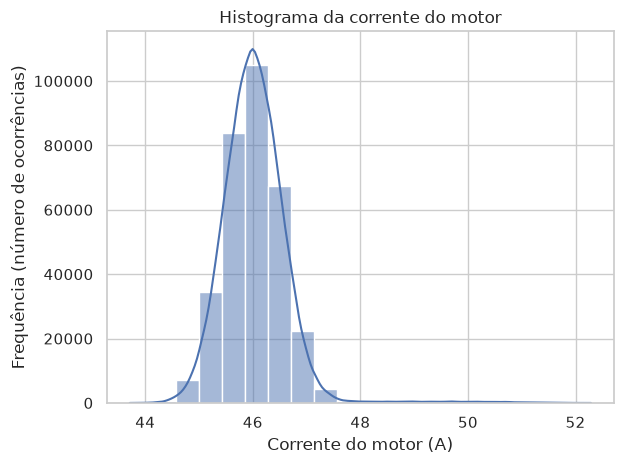

In [4]:
ax = sns.histplot(data=df, x="motor_current", bins=20, kde=True)

ax.set_title("Histograma da corrente do motor")
ax.set_xlabel("Corrente do motor (A)")
ax.set_ylabel("Frequência (número de ocorrências)")
ax.figure.tight_layout()
ax.figure.savefig("../images/results/example_histogram.png")

### Exemplo de gráfico de linha

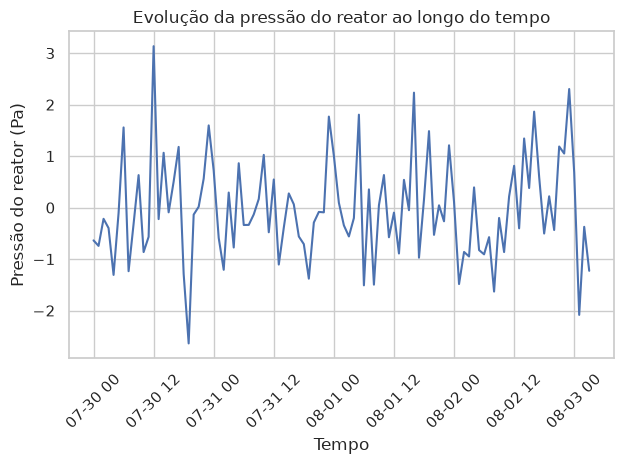

In [5]:
import numpy as np

random_data = np.random.normal(loc=0, scale=1, size=100)
timestamps = pd.date_range(start="2026-07-30", periods=100, freq="h")
plot_df = pd.DataFrame({"timestamp": timestamps, "reactor_pressure": random_data})

ax = sns.lineplot(data=plot_df, x="timestamp", y="reactor_pressure")
ax.set_title("Evolução da pressão do reator ao longo do tempo")
ax.set_xlabel("Tempo")
ax.set_ylabel("Pressão do reator (Pa)")
ax.tick_params(axis="x", labelrotation=45)
ax.figure.tight_layout()
ax.figure.savefig("../images/results/example_plot.png")

### Exemplo de filtrado por timestamp

In [6]:
start = pd.Timestamp("2024-01-01 00:00:00")
end = pd.Timestamp("2024-01-01 01:00:00")

filtered = df[df["timestamp"].between(start, end, inclusive="both")]["operating_regime"]
filtered.tail()

259256    A
259257    A
259258    A
259259    A
259260    A
Name: operating_regime, dtype: str